In [1]:
"""
>>> docker compose run rl bash /workspace/start_jupyter.sh
::: http://127.0.0.1:8888/?token=mujoco
"""

import os
import sys
import time
import math
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="gymnasium")

import numpy as np              # type: ignore
import pandas as pd             # type: ignore
import matplotlib.pyplot as plt # type: ignore
print(f"Python: {sys.version}\n")

import mujoco                   # type: ignore
import myosuite                 # type: ignore
import gymnasium as gym         # type: ignore
import stable_baselines3        # type: ignore

import torch                    # pyright: ignore[reportMissingImports]
import torch.nn as nn           # pyright: ignore[reportMissingImports]
import torch.optim as optim     # pyright: ignore[reportMissingImports]

print("MuJoCo:", mujoco.__version__)
print("Myosuite:", myosuite.__version__)
print("Gymnasium:", gym.__version__)
print("Stable Baselines3:", stable_baselines3.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())

Python: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]

MyoSuite:> Registering Myo Envs
MuJoCo: 3.3.0
Myosuite: 2.11.6
Gymnasium: 0.29.1
Stable Baselines3: 2.7.1
PyTorch: 2.5.1+cu121
GPU: True


In [2]:
all_envs = gym.envs.registry.keys()
myo_envs = sorted([e for e in all_envs if 'myo' in e.lower()])

print(f"Total MyoSuite envs: {len(myo_envs)} | All environments: {len(all_envs)}\n")
print(list(all_envs)), print(myo_envs)

Total MyoSuite envs: 394 | All environments: 449

['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v2', 'LunarLanderContinuous-v2', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v2', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v0', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Pusher-v2', 'Pusher-v4', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Humanoid-v2', 'Humanoid-v3', 'Humanoid-v4', 'HumanoidStandup-v2', 'HumanoidStandup-v4', 'GymV21Environment-v0', 'GymV26Environment-v0', 'motorFingerReachFixed-v0', '

(None, None)

Observation space: Box(-10.0, 10.0, (170,), float32)
Action space:      Box(-1.0, 1.0, (45,), float32)


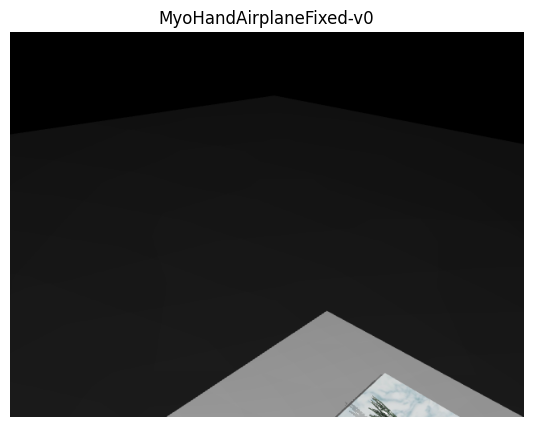


Observation shape: (170,)
First 6 values:    [0. 0. 0. 0. 0. 0.]


In [4]:
env = gym.make("MyoHandAirplaneFixed-v0")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")

obs, _ = env.reset()

# Render offscreen directly via MuJoCo sim
frame = env.sim.renderer.render_offscreen(
    width=640,
    height=480,
    camera_id=0
)

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("MyoHandAirplaneFixed-v0")
plt.show()

print(f"\nObservation shape: {obs.shape}")
print(f"First 6 values:    {obs[:6].round(4)}")

env.close()

In [5]:
frame = env.unwrapped.sim.render(width=640, height=480, mode='offscreen')


AttributeError: 'DMSimScene' object has no attribute 'render'